In [33]:
import tensorflow as tf
import os

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

DATA_DIR = r"D:\DATA SCIENCE\Projects DM\PRCP-1001-RiceLeaf\Data"

print("Classes:", os.listdir(DATA_DIR))

TensorFlow Version: 2.20.0
GPU Available: []
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


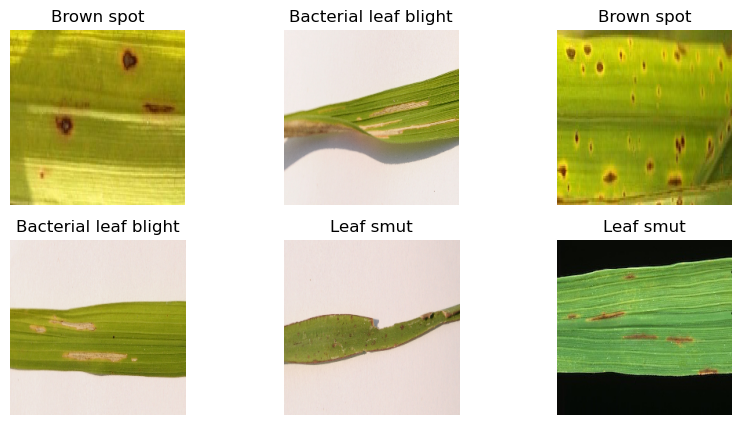

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels = next(train_gen)

class_names = list(train_gen.class_indices.keys())

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')

plt.show()

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7,1.3],
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224,224),
    batch_size=8,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224,224),
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


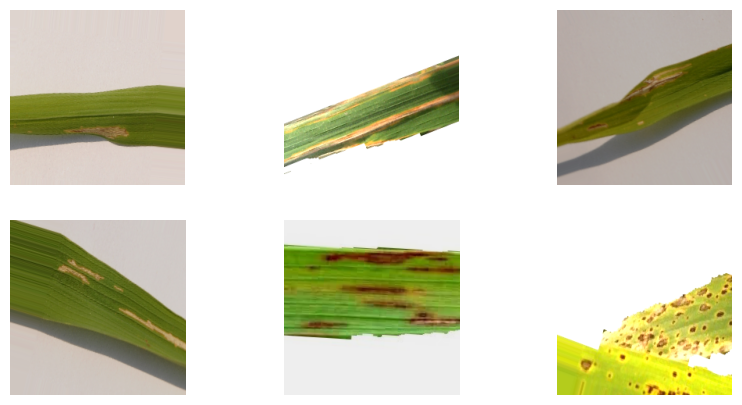

In [37]:
images, labels = next(train_gen)

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

In [38]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(3, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 759ms/step - accuracy: 0.4479 - loss: 1.5572 - val_accuracy: 0.6957 - val_loss: 0.7902 - learning_rate: 0.0010
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 502ms/step - accuracy: 0.7604 - loss: 0.6969 - val_accuracy: 0.7391 - val_loss: 0.6282 - learning_rate: 0.0010
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 542ms/step - accuracy: 0.8125 - loss: 0.4941 - val_accuracy: 0.7391 - val_loss: 0.5832 - learning_rate: 0.0010
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 480ms/step - accuracy: 0.8333 - loss: 0.6351 - val_accuracy: 0.6957 - val_loss: 0.6408 - learning_rate: 0.0010
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 470ms/step - accuracy: 0.8333 - loss: 0.3415 - val_accuracy: 0.6522 - val_loss: 0.6163 - learning_rate: 0.0010
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 477ms/step - accuracy: 0.8854 - loss: 0.3089 - val_accuracy: 0.7826 - val_loss: 0.6094 - learning_rate: 0.0010
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 515ms/step - accuracy: 0.9479 - loss: 0.1616 -

In [40]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 897ms/step


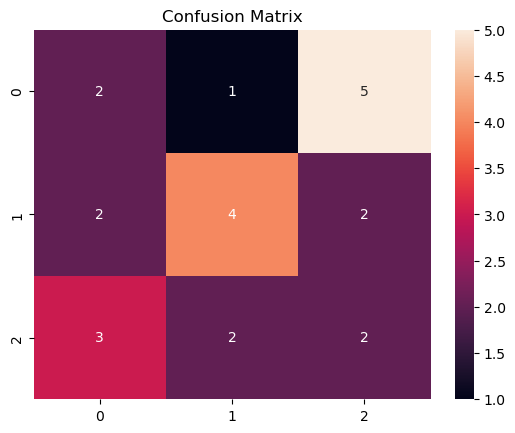

              precision    recall  f1-score   support

           0       0.29      0.25      0.27         8
           1       0.57      0.50      0.53         8
           2       0.22      0.29      0.25         7

    accuracy                           0.35        23
   macro avg       0.36      0.35      0.35        23
weighted avg       0.37      0.35      0.35        23



In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

val_gen.reset()
preds = model.predict(val_gen)

y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))

In [43]:
val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(224,224),
    batch_size=8,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # 🔥 IMPORTANT FIX
)

Found 23 images belonging to 3 classes.


In [44]:
val_gen.reset()
preds = model.predict(val_gen)

import numpy as np
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.78      0.88      0.82         8
           2       0.83      0.71      0.77         7

    accuracy                           0.87        23
   macro avg       0.87      0.86      0.86        23
weighted avg       0.87      0.87      0.87        23



In [46]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"D:\DATA SCIENCE\Projects DM\PRCP-1001-RiceLeaf\Data\Bacterial leaf blight\DSC_0365.JPG"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

class_names = list(train_gen.class_indices.keys())
print("Prediction:", class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Bacterial leaf blight


In [47]:
pred = model.predict(img_array)

class_names = list(train_gen.class_indices.keys())

pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

print("Prediction:", pred_class)
print("Confidence:", round(confidence * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Prediction: Bacterial leaf blight
Confidence: 94.84 %


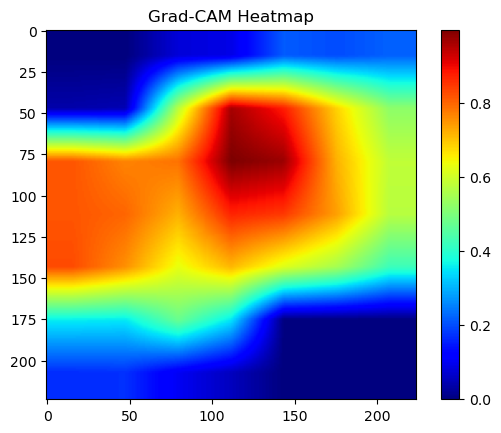

In [51]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Last conv layer of MobileNetV2
last_conv_layer_name = "Conv_1"

# Create model
grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer_name).output, model.output]
)

# Gradient calculation
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_idx = np.argmax(predictions[0])
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

# 🔥 IMPORTANT FIX
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

# Multiply feature maps
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Normalize
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# Resize to original image size
heatmap = cv2.resize(heatmap, (224,224))

# Show heatmap
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

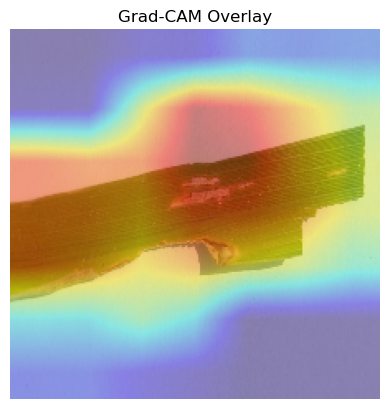

In [52]:
# Load original image properly
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

# Convert heatmap to RGB
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# 🔥 IMPORTANT FIX: ensure same shape
if heatmap.shape != img.shape:
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

# Overlay
overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

# Show result
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis('off')
plt.show()

In [53]:
model.save("rice_disease_model.h5")

In [54]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [55]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)